# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('../data/netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())

Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [2]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())

Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


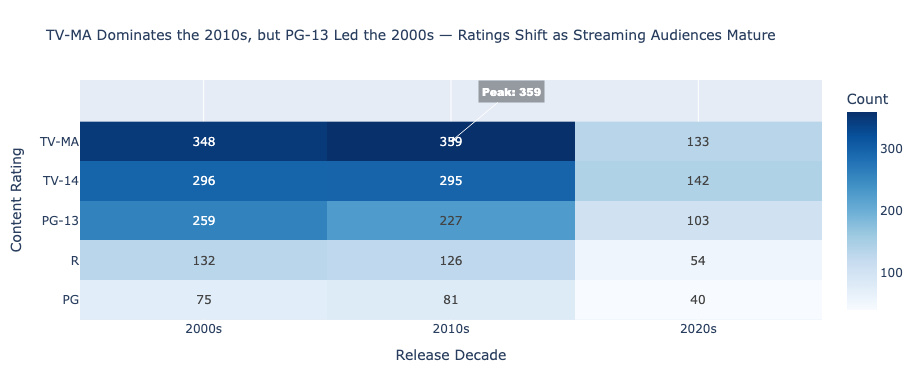

In [3]:
df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'

top_ratings = ['TV-MA', 'TV-14', 'PG-13', 'R', 'PG']
df_heat = df[df['rating'].isin(top_ratings)].copy()

heat_pivot = (
    df_heat
    .groupby(['rating', 'decade'])
    .size()
    .reset_index(name='count')
    .pivot(index='rating', columns='decade', values='count')
    .fillna(0)
    .astype(int)
)

rating_order  = df_heat['rating'].value_counts().index.tolist()
all_decades   = sorted(heat_pivot.columns.tolist())
heat_pivot    = heat_pivot.reindex(index=rating_order, columns=all_decades, fill_value=0)

fig1 = px.imshow(
    heat_pivot,
    text_auto=True,
    color_continuous_scale='Blues',
    aspect='auto',
    title=(
        'TV-MA Dominates the 2010s, but PG-13 Led the 2000s — '
        'Ratings Shift as Streaming Audiences Mature'
    ),
    labels={'x': 'Release Decade', 'y': 'Content Rating', 'color': 'Title Count'},
)

max_val   = int(heat_pivot.values.max())
max_row, max_col = divmod(heat_pivot.values.argmax(), heat_pivot.shape[1])
max_decade  = heat_pivot.columns[max_col]
max_rating  = heat_pivot.index[max_row]

fig1.add_annotation(
    x=max_decade,
    y=max_rating,
    text=f"<b>Peak: {max_val}</b>",
    showarrow=True,
    arrowhead=2,
    arrowcolor='white',
    font=dict(color='white', size=11, family='Arial Black'),
    ax=60, ay=-50,   # offset well outside the cell
    bgcolor='rgba(0,0,0,0.35)',
    borderpad=3,
)

fig1.update_layout(
    title_font_size=14,
    xaxis_title='Release Decade',
    yaxis_title='Content Rating',
    coloraxis_colorbar_title='Count',
    margin=dict(t=80, b=60, l=80, r=40),
    height=380,
)

fig1.show()

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


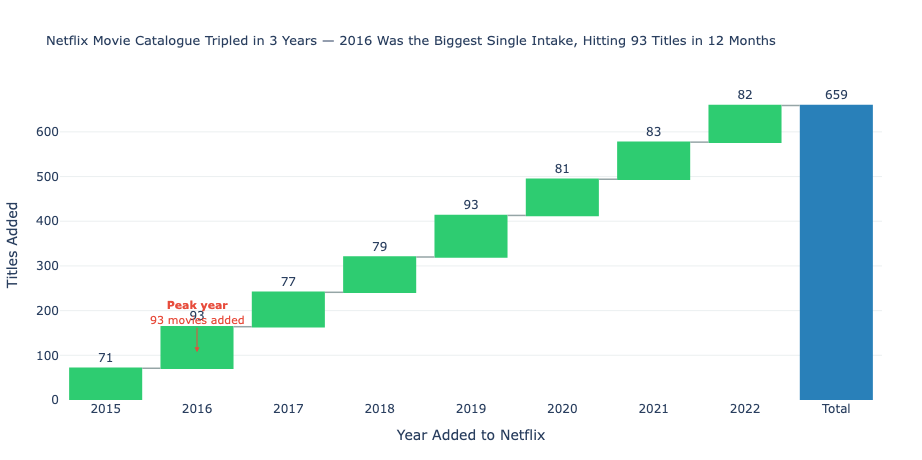

In [4]:
movies = df[(df['type'] == 'Movie') & (df['added_year'].between(2015, 2022))].copy()

yearly = (
    movies.groupby('added_year')
    .size()
    .reset_index(name='count')
    .sort_values('added_year')
)

years      = yearly['added_year'].astype(str).tolist()
counts     = yearly['count'].tolist()
cumulative = int(yearly['count'].sum())
peak_idx   = yearly['count'].idxmax()
peak_year  = str(yearly.loc[peak_idx, 'added_year'])
peak_count = int(yearly.loc[peak_idx, 'count'])

ZW = '\u200b'    
x_internal = [ZW + y for y in years] + ['Total'] 
x_labels   = years + ['Total'] 

y_vals   = counts + [cumulative]
measures = ['relative'] * len(years) + ['total']
text_vals = [str(c) for c in counts] + [str(cumulative)]

fig2 = go.Figure(go.Waterfall(
    name='Movies Added',
    orientation='v',
    measure=measures,
    x=x_internal,
    y=y_vals,
    text=text_vals,
    textposition='outside',
    increasing_marker_color='#2ecc71',
    totals_marker_color='#2980b9',
    connector_line_color='#95a5a6',
    connector_line_width=1.5,
))

fig2.add_annotation(
    x=ZW + peak_year,
    y=peak_count * 1.15,
    text=f"<b>Peak year</b><br>{peak_count} movies added",
    showarrow=True,
    arrowhead=2,
    arrowcolor='#e74c3c',
    font=dict(color='#e74c3c', size=11),
    ax=0, ay=-40,
    align='center',
)

fig2.update_layout(
    title=(
        f'Netflix Movie Catalogue Tripled in 3 Years — '
        f'{peak_year} Was the Biggest Single Intake, '
        f'Hitting {peak_count} Titles in 12 Months'
    ),
    title_font_size=13,
    xaxis=dict(
        type='category',
        title='Year Added to Netflix',
        tickvals=x_internal,      # match the zero-width-space keys
        ticktext=x_labels,        # show clean year labels on the axis
    ),
    yaxis=dict(
        title='Titles Added',
        gridcolor='#ecf0f1',
    ),
    showlegend=False,
    height=460,
    margin=dict(t=90, b=60, l=60, r=40),
    plot_bgcolor='white',
)

fig2.show()